# Day 3 Project - Real photo vs AI-generated

**Path A (research question):** *Can a CNN tell a real photograph from an AI-generated image - and **what** does it look at to decide?*

Pipeline (CNN + transfer learning + Grad-CAM):
1. Load two folders of images: `real/` and `ai/`.
2. Fine-tune **ResNet18** to classify real vs AI.
3. Measure it: accuracy + **confusion matrix** (artifact 1).
4. Explain it: **Grad-CAM** heatmaps showing where the model looks (artifact 2).

Runs locally on Apple GPU (MPS). Grad-CAM runs on CPU (gradient conv ops are flaky on MPS).

## 1. Setup

In [11]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

%matplotlib inline
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def pick_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = pick_device()
print("device:", device)

device: mps


## 2. Get your data

Put images into this layout (subfolder name = label):

```
data_real_vs_ai/
  real/   <- real photographs (your own, or a photo dataset)
  ai/     <- AI-generated images (Stable Diffusion / DALL-E / Midjourney)
```

**Two easy ways to fill it:**
- **Your own (cleanest for "data you gathered yourself"):** ~100 real photos + ~100 you generate yourself.
- **Ready-made - CIFAKE** (60k real CIFAR + 60k Stable-Diffusion fakes). On Kaggle: `birdy654/cifake-real-and-ai-generated-synthetic-images`, or HuggingFace `dragonintelligence/CIFAKE-image-dataset`. Download, then arrange a slice into `real/` and `ai/`.

Aim for at least ~150 images per class to start.

In [18]:
DATA_DIR = "data_real_vs_ai"

# friendly check so the notebook tells you what's missing instead of crashing
def count_images(d):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    if not os.path.isdir(d):
        return 0
    return sum(1 for f in os.listdir(d) if f.lower().endswith(exts))

n_real = count_images(os.path.join(DATA_DIR, "real"))
n_ai   = count_images(os.path.join(DATA_DIR, "ai"))
print(f"real: {n_real} images | ai: {n_ai} images")

if n_real < 5 or n_ai < 5:
    raise SystemExit(
        f"Not enough images yet. Create '{DATA_DIR}/real/' and '{DATA_DIR}/ai/' "
        "and add photos to each (see the markdown cell above), then re-run."
    )

real: 500 images | ai: 500 images


## 3. Load & split

In [19]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()  # resize + normalize to match the pretrained net

dataset = datasets.ImageFolder(DATA_DIR, transform=preprocess)
print("classes:", dataset.classes, "| total:", len(dataset))

n_test = max(1, int(len(dataset) * 0.25))
n_train = len(dataset) - n_test
train_ds, test_ds = random_split(
    dataset, [n_train, n_test], generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=16)
print("train:", n_train, "| test:", n_test)

classes: ['ai', 'real'] | total: 1006
train: 755 | test: 251


## 4. Fine-tune ResNet18

Take a pretrained ResNet18, swap the classifier for a 2-class head, freeze the backbone, then unfreeze the last block (`layer4`) and the head and train a few epochs with a small learning rate.

In [20]:
from torchvision.models import resnet18

model = resnet18(weights=weights)
model.fc = nn.Linear(512, 2)
for p in model.parameters():
    p.requires_grad = False
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True
model = model.to(device)

opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 4
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in tqdm(train_loader, desc=f"epoch {epoch+1}/{EPOCHS}", leave=False):
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
print("training done")

epoch 1/4:   0%|          | 0/48 [00:00<?, ?it/s]

epoch 2/4:   0%|          | 0/48 [00:00<?, ?it/s]

epoch 3/4:   0%|          | 0/48 [00:00<?, ?it/s]

epoch 4/4:   0%|          | 0/48 [00:00<?, ?it/s]

training done


## 5. Artifact 1: accuracy + confusion matrix

test accuracy: 0.801


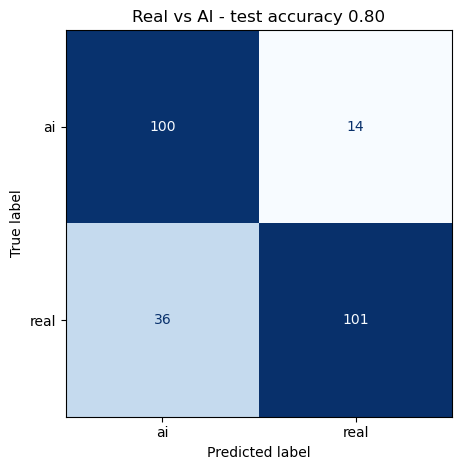

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        y_pred += model(xb.to(device)).argmax(1).cpu().tolist()
        y_true += yb.tolist()

acc = accuracy_score(y_true, y_pred)
print("test accuracy:", round(acc, 3))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset.classes)
disp.plot(cmap="Blues", colorbar=False)
plt.title(f"Real vs AI - test accuracy {acc:.2f}")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=140); plt.show()

## 6. Artifact 2: Grad-CAM - where does it look?

Grad-CAM paints a heatmap over the pixels that most drove the prediction. Run it on a few test images to see **what betrays an AI image** to the model (backgrounds, textures, edges...). Runs on CPU.

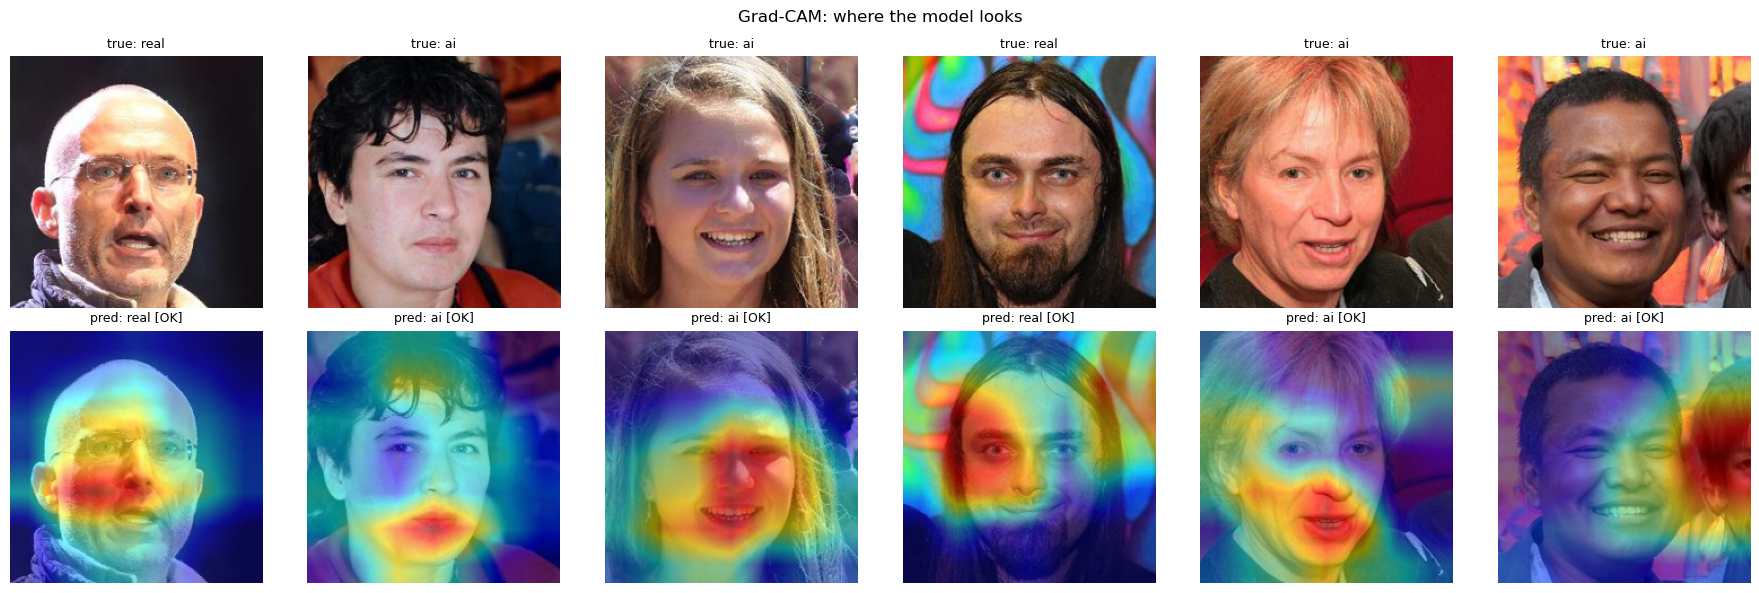

In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

# a CPU copy of the trained model for gradients
cam_model = resnet18(weights=weights)
cam_model.fc = nn.Linear(512, 2)
cam_model.load_state_dict({k: v.cpu() for k, v in model.state_dict().items()})
cam_model.eval()

# pick a few test images (paths live in dataset.samples via the Subset indices)
sample_idx = list(test_ds.indices)[:6]

fig, axes = plt.subplots(2, len(sample_idx), figsize=(3 * len(sample_idx), 6))
with GradCAM(model=cam_model, target_layers=[cam_model.layer4[-1]]) as cam:
    for col, idx in enumerate(sample_idx):
        path, true_c = dataset.samples[idx]
        pil = Image.open(path).convert("RGB")
        rgb = np.array(pil.resize((224, 224))).astype(np.float32) / 255.0
        x = preprocess(pil).unsqueeze(0)
        pred = cam_model(x).argmax(1).item()
        heat = cam(input_tensor=x)[0]
        overlay = show_cam_on_image(rgb, heat, use_rgb=True)
        axes[0, col].imshow(rgb); axes[0, col].axis("off")
        axes[0, col].set_title(f"true: {dataset.classes[true_c]}", fontsize=9)
        axes[1, col].imshow(overlay); axes[1, col].axis("off")
        mark = "OK" if pred == true_c else "WRONG"
        axes[1, col].set_title(f"pred: {dataset.classes[pred]} [{mark}]", fontsize=9)
plt.suptitle("Grad-CAM: where the model looks")
plt.tight_layout(); plt.savefig("gradcam.png", dpi=140); plt.show()

## 7. Save the model

In [17]:
torch.save(model.state_dict(), "real_vs_ai_resnet18.pt")
print("saved real_vs_ai_resnet18.pt, confusion_matrix.png, gradcam.png")

saved real_vs_ai_resnet18.pt, confusion_matrix.png, gradcam.png


## Your finding & where to take it next

**Write up what you saw** (this is the Path A story):
- How accurate was it? Which direction did it confuse (real->ai or ai->real)?
- From Grad-CAM, *what* did it key on - object, background, texture, edges?

**A strong extra experiment (recommended):** train on images from **one** generator, then test on a **different** generator (or a different image domain). Detectors usually generalize poorly - accuracy drops a lot. That is the real, interesting finding: the model learns the fingerprint of a *specific* generator, not "AI-ness" in general.

**Other extensions:** collect the confidently-wrong cases; add more classes (a third generator); try feature-extraction (freeze everything, train only the head) and compare.